# KO Case 02: Lineage-Resolved Simulation vs Experimental Severity 

This notebook reproduces the knockout analysis logic that compares **simulated family-member regulatory strength** against **experimental KO severity** across lineages.

Biological objective:
1. Trace data lineage from KO inference outputs to GLI/SCN summary tables.
2. Assemble summary-ready tables across key developmental trajectories.
3. Visualize simulation-vs-experimental concordance for GLI and SCN families.

Import packages and set deterministic seeds.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Seed set to {SEED}')

Seed set to 0


Set paths and outputs for KO summary reconstruction.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


repo_root = find_repo_root(Path.cwd().resolve())
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'knockout_section'
resources_root = tutorials_root / 'resources' / 'knockout'
legacy_root = resources_root / 'gene_compensation_clean_github'
legacy_gli_root = legacy_root / 'gli'
legacy_scn_root = legacy_root / 'scn'
results_full_root = resources_root / 'results_full'
data_root = repo_root / 'data' / 'knockout'

case_output_root = tutorials_root / 'outputs' / 'knockout_simulation_experimental_panels'
TABLE_DIR = case_output_root / '01_tables'
FIG_DIR = case_output_root / '02_figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

GLI_EFFECTS_PATH = legacy_gli_root / 'output' / 'gli_effects_by_celltype.csv'
SCN_EFFECTS_PATH = legacy_scn_root / 'output' / 'scn_effects_by_celltype.csv'

required = {'gli_effects': GLI_EFFECTS_PATH, 'scn_effects': SCN_EFFECTS_PATH}
missing = [f'{k}: {v}' for k, v in required.items() if not v.exists()]
if missing:
    raise FileNotFoundError('Missing required files\n' + '\n'.join(missing))

print('Repository root :', repo_root)
print('Tutorial root   :', tutorials_root.relative_to(repo_root))
print('Case output root:', case_output_root.relative_to(repo_root))


Repository root : /workspace/fuchenghao/Navigo_unified_repo
Tutorial root   : docs/tutorials
Case output root: docs/tutorials/outputs/knockout_simulation_experimental_panels


## Step 1: Trace knockout data lineage
Map script-to-artifact dependencies for reproducible summary generation.

In [3]:
pipeline_rows = [
    {
        'stage': 'Model inference outputs',
        'script': resources_root / 'model_inference' / 'infer_forward_dko.py',
        'artifact': results_full_root,
    },
    {
        'stage': 'GLI expression-change aggregation',
        'script': legacy_gli_root / 'expression_change_cell_type.py',
        'artifact': legacy_gli_root / 'output' / 'Limb#mesenchyme#trajectory' / 'expression_change_results.csv',
    },
    {
        'stage': 'GLI effect summary for panel',
        'script': legacy_gli_root / 'expression_deg_relationship.py',
        'artifact': GLI_EFFECTS_PATH,
    },
    {
        'stage': 'SCN expression-change aggregation',
        'script': legacy_scn_root / 'expression_change_cell_type.py',
        'artifact': legacy_scn_root / 'output' / 'Limb#mesenchyme#trajectory' / 'expression_change_results.csv',
    },
    {
        'stage': 'SCN effect summary for panel',
        'script': legacy_scn_root / 'expression_deg_relationship.py',
        'artifact': SCN_EFFECTS_PATH,
    },
]

provenance = pd.DataFrame(pipeline_rows)
provenance['script_exists'] = provenance['script'].map(Path.exists)
provenance['artifact_exists'] = provenance['artifact'].map(Path.exists)
provenance['script'] = provenance['script'].map(lambda p: str(p.relative_to(repo_root)))
provenance['artifact'] = provenance['artifact'].map(lambda p: str(p.relative_to(repo_root)))

provenance_out = TABLE_DIR / '01_pipeline_provenance.csv'
provenance.to_csv(provenance_out, index=False)
print('Saved:', provenance_out.relative_to(repo_root))
provenance

Saved: docs/tutorials/outputs/knockout_simulation_experimental_panels/01_tables/01_pipeline_provenance.csv


,stage,script,artifact,script_exists,artifact_exists
0,Model inference outputs,docs/tutorials/resources/knockout/model_infere...,docs/tutorials/resources/knockout/results_full,True,True
1,GLI expression-change aggregation,docs/tutorials/resources/knockout/gene_compens...,docs/tutorials/resources/knockout/gene_compens...,True,True
2,GLI effect summary for panel,docs/tutorials/resources/knockout/gene_compens...,docs/tutorials/resources/knockout/gene_compens...,True,True
3,SCN expression-change aggregation,docs/tutorials/resources/knockout/gene_compens...,docs/tutorials/resources/knockout/gene_compens...,True,True
4,SCN effect summary for panel,docs/tutorials/resources/knockout/gene_compens...,docs/tutorials/resources/knockout/gene_compens...,True,True


## Step 2: Assemble summary-ready GLI/SCN summary tables
Filter to canonical KO lineages and verify expected perturbation result folders.

In [4]:
gli_effects = pd.read_csv(GLI_EFFECTS_PATH).rename(columns={'Unnamed: 0': 'cell_type'})
scn_effects = pd.read_csv(SCN_EFFECTS_PATH).rename(columns={'Unnamed: 0': 'cell_type'})

panel_cells = [
    'Limb#mesenchyme#trajectory',
    'Chondrocyte#trajectory',
    'Intermediate#mesoderm#trajectory',
    'Motor#neuron#trajectory',
    'Spinal#cord#dorsal#trajectory',
    'Osteoblast#trajectory',
]

gli_panel = gli_effects[gli_effects['cell_type'].isin(panel_cells)].copy()
scn_panel = scn_effects[scn_effects['cell_type'].isin(panel_cells)].copy()

gli_out = TABLE_DIR / '01_gli_effects_by_celltype.csv'
scn_out = TABLE_DIR / '01_scn_effects_by_celltype.csv'
gli_panel.to_csv(gli_out, index=False)
scn_panel.to_csv(scn_out, index=False)

check_names = ['Gli1', 'Gli2', 'Gli3', 'Gli1_Gli3', 'Scn10a', 'Scn11a', 'Scn9a', 'Scn7a', 'Scn10a_Scn11a']
check_rows = []
for name in check_names:
    check_rows.append({'perturbation_name': name, 'num_result_dirs': len(list(results_full_root.glob(f'forward_{name}_*')))})

check_df = pd.DataFrame(check_rows)
check_out = TABLE_DIR / '01_results_full_presence_check.csv'
check_df.to_csv(check_out, index=False)

print('Saved:', gli_out.relative_to(repo_root))
print('Saved:', scn_out.relative_to(repo_root))
print('Saved:', check_out.relative_to(repo_root))



Saved: docs/tutorials/outputs/knockout_simulation_experimental_panels/01_tables/01_gli_effects_by_celltype.csv
Saved: docs/tutorials/outputs/knockout_simulation_experimental_panels/01_tables/01_scn_effects_by_celltype.csv
Saved: docs/tutorials/outputs/knockout_simulation_experimental_panels/01_tables/01_results_full_presence_check.csv


## Step 3: Materialize simulation vs experimental summary view
Render GLI/SCN family comparison without extra visual annotations (content-focused view).

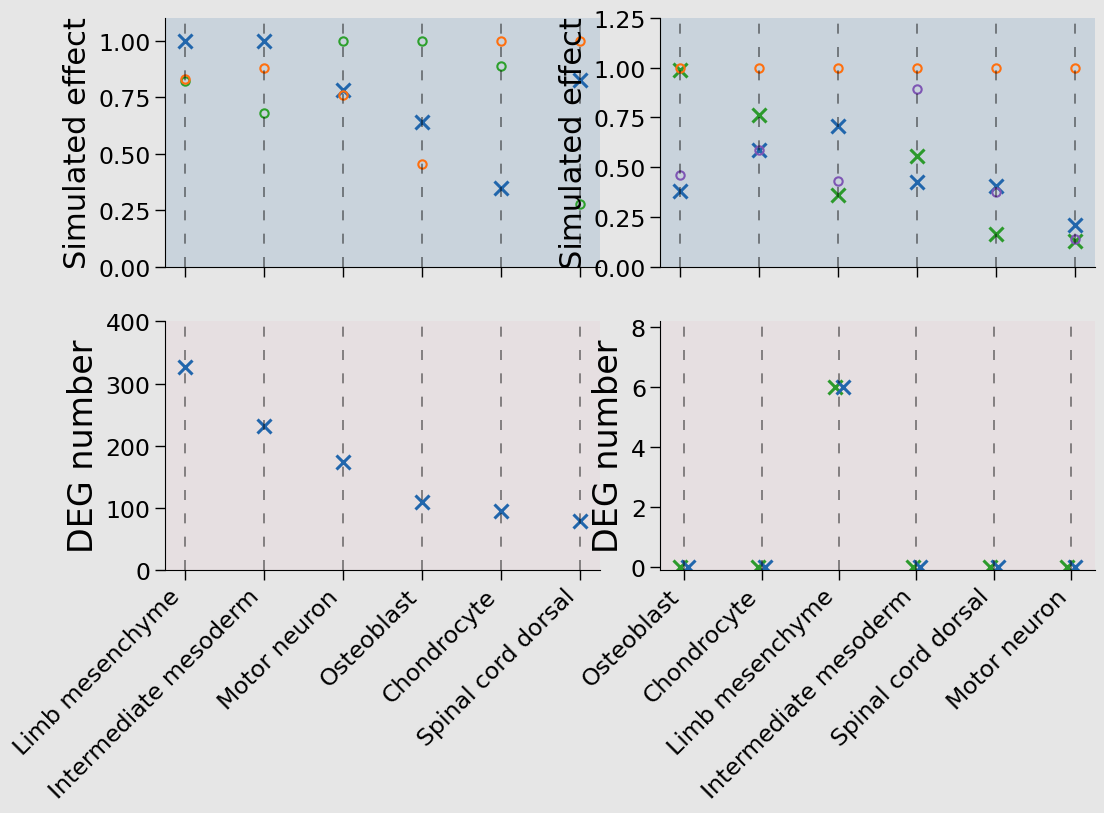

Saved figure: docs/tutorials/outputs/knockout_simulation_experimental_panels/02_figures/01_simulation_experimental_panel_ij.png


In [5]:
left_order = [
    'Limb#mesenchyme#trajectory',
    'Intermediate#mesoderm#trajectory',
    'Motor#neuron#trajectory',
    'Osteoblast#trajectory',
    'Chondrocyte#trajectory',
    'Spinal#cord#dorsal#trajectory',
]
right_order = [
    'Osteoblast#trajectory',
    'Chondrocyte#trajectory',
    'Limb#mesenchyme#trajectory',
    'Intermediate#mesoderm#trajectory',
    'Spinal#cord#dorsal#trajectory',
    'Motor#neuron#trajectory',
]
label_map = {
    'Limb#mesenchyme#trajectory': 'Limb mesenchyme',
    'Intermediate#mesoderm#trajectory': 'Intermediate mesoderm',
    'Motor#neuron#trajectory': 'Motor neuron',
    'Osteoblast#trajectory': 'Osteoblast',
    'Chondrocyte#trajectory': 'Chondrocyte',
    'Spinal#cord#dorsal#trajectory': 'Spinal cord dorsal',
}

gli_idx = gli_panel.set_index('cell_type')
scn_idx = scn_panel.set_index('cell_type')
gli_left = gli_idx.loc[left_order]
scn_right = scn_idx.loc[right_order]

left_plot_tbl = pd.DataFrame({
    'cell_type': left_order,
    'label': [label_map[c] for c in left_order],
    'Gli1_normalized': gli_left['Gli1_normalized'].values,
    'Gli2_normalized': gli_left['Gli2_normalized'].values,
    'Gli3_normalized': gli_left['Gli3_normalized'].values,
    'deg_count': gli_left['deg_count'].values,
})
right_plot_tbl = pd.DataFrame({
    'cell_type': right_order,
    'label': [label_map[c] for c in right_order],
    'Scn10a_normalized': scn_right['Scn10a_normalized'].values,
    'Scn11a_normalized': scn_right['Scn11a_normalized'].values,
    'Scn9a_normalized': scn_right['Scn9a_normalized'].values,
    'Scn7a_normalized': scn_right['Scn7a_normalized'].values,
    'deg_count': scn_right['deg_count'].values,
})
left_plot_tbl.to_csv(TABLE_DIR / '01_panel_ij_left_plot_table.csv', index=False)
right_plot_tbl.to_csv(TABLE_DIR / '01_panel_ij_right_plot_table.csv', index=False)

x_left = np.arange(len(left_order))
x_right = np.arange(len(right_order))

fig, axs = plt.subplots(2, 2, figsize=(12.0, 8.0), gridspec_kw={'hspace': 0.22, 'wspace': 0.14})
(ax_tl, ax_tr), (ax_bl, ax_br) = axs

for ax in [ax_tl, ax_tr]:
    ax.set_facecolor('#c9d3dc')
for ax in [ax_bl, ax_br]:
    ax.set_facecolor('#e6dfe1')

ax_tl.plot(x_left, gli_left['Gli1_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#2ca02c')
ax_tl.plot(x_left, gli_left['Gli2_normalized'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
ax_tl.plot(x_left, gli_left['Gli3_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#ff6f0e')
for x in x_left:
    ax_tl.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_tl.set_ylim(0, 1.1)
ax_tl.set_ylabel('Simulated effect', fontsize=22)
ax_tl.set_xticks(x_left)
ax_tl.set_xticklabels([])

ax_tr.plot(x_right, scn_right['Scn10a_normalized'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2c9a2c')
ax_tr.plot(x_right, scn_right['Scn11a_normalized'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
ax_tr.plot(x_right, scn_right['Scn9a_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#ff6f0e')
ax_tr.plot(x_right, scn_right['Scn7a_normalized'], linestyle='None', marker='o', markersize=6, markerfacecolor='none', markeredgewidth=1.5, markeredgecolor='#7e56b4')
for x in x_right:
    ax_tr.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_tr.set_ylim(0, 1.25)
ax_tr.set_ylabel('Simulated effect', fontsize=22)
ax_tr.set_xticks(x_right)
ax_tr.set_xticklabels([])

ax_bl.plot(x_left, gli_left['deg_count'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
for x in x_left:
    ax_bl.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_bl.set_ylim(0, 400)
ax_bl.set_ylabel('DEG number', fontsize=24)
ax_bl.set_xticks(x_left)
ax_bl.set_xticklabels([label_map[c] for c in left_order], rotation=45, ha='right', fontsize=16)

ax_br.plot(x_right - 0.05, scn_right['deg_count'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2c9a2c')
ax_br.plot(x_right + 0.05, scn_right['deg_count'], linestyle='None', marker='x', markersize=10, markeredgewidth=2.2, color='#2166ac')
for x in x_right:
    ax_br.axvline(x, color='k', lw=1.2, ls=(0, (6, 8)), alpha=0.5)
ax_br.set_ylim(-0.1, 8.2)
ax_br.set_ylabel('DEG number', fontsize=24)
ax_br.set_xticks(x_right)
ax_br.set_xticklabels([label_map[c] for c in right_order], rotation=45, ha='right', fontsize=16)

for ax in [ax_tl, ax_tr, ax_bl, ax_br]:
    ax.tick_params(axis='both', labelsize=17, width=1.0, length=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.subplots_adjust(top=0.94, bottom=0.25)
fig.patch.set_facecolor('#e6e6e6')

panel_out = FIG_DIR / '01_simulation_experimental_panel_ij.png'
fig.savefig(panel_out, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved figure:', panel_out.relative_to(repo_root))

## Biological interpretation guide for lineage-specific compensation
- **GLI family trend**: lineages with stronger simulated `Gli2` impact generally show larger experimental `Gli2` KO DEG burden.
- **Compensation logic**: where simulated `Gli1/Gli3` signals are relatively strong, KO severity can be buffered, consistent with paralog compensation.
- **SCN family contrast**: low DEG burden for `Scn10a/Scn11a`-related KO contexts alongside stronger alternative SCN-family signals is consistent with buffering by paralogs (e.g., `Scn9a`).
- **Biological takeaway**: lineage context determines how much a gene-family perturbation propagates to transcriptome-scale disruption.